# Notebook 1: Core Python Fundamentals
### ML Skills Refresh Curriculum — Module 1 of 30

---

## 🎯 Learning Objectives

By the end of this notebook, you will have a solid working knowledge of the Python building blocks that underpin every data science and ML workflow:

| # | Topic | Why It Matters in ML |
|---|-------|----------------------|
| 1 | Variables & Data Types | Every feature, label, and hyperparameter is a variable |
| 2 | Lists | Storing rows of data, feature arrays, batch results |
| 3 | Dictionaries | Config objects, label mappings, metrics containers |
| 4 | For / While Loops | Iterating over datasets, training epochs |
| 5 | Custom Functions | Reusable preprocessing and evaluation helpers |

---

> **Dataset Context:** Throughout this notebook we use a tiny, hand-crafted **Student Exam Score** dataset — five students, each with a name, hours studied, and final exam score. It is intentionally simple so the focus stays on the Python concepts, not the data.

---
## Section 1 — Variables & Data Types

### 📖 The Logic

A **variable** is a named container that points to a value stored in memory. Python is *dynamically typed*, meaning you do not declare a type — Python infers it from the value you assign.

The four primitive types you will use constantly in ML are:

| Type | Python keyword | Example | Typical ML use |
|------|---------------|---------|----------------|
| Integer | `int` | `42` | Epoch count, class label |
| Floating-point | `float` | `0.95` | Accuracy, loss value |
| String | `str` | `'relu'` | Activation name, file path |
| Boolean | `bool` | `True` | Flags, early-stopping switch |

You can always inspect a variable's type with the built-in `type()` function.

In [1]:
# ── Integer: whole numbers, no decimal point ──────────────────────────────────
num_students = 5            # how many students are in our dataset

# ── Float: numbers with a decimal point ───────────────────────────────────────
passing_threshold = 50.0    # minimum score to pass the exam

# ── String: text, always wrapped in quotes ────────────────────────────────────
course_name = "Intro to Data Science"   # name of the course

# ── Boolean: only two possible values — True or False ─────────────────────────
curve_applied = False       # flag: was a grade curve applied to this exam?

# ── Print each variable alongside its type so we can verify ───────────────────
print(f"num_students   : {num_students}   → type: {type(num_students)}")
print(f"passing_threshold: {passing_threshold} → type: {type(passing_threshold)}")
print(f"course_name    : {course_name!r} → type: {type(course_name)}")
print(f"curve_applied  : {curve_applied}  → type: {type(curve_applied)}")

num_students   : 5   → type: <class 'int'>
passing_threshold: 50.0 → type: <class 'float'>
course_name    : 'Intro to Data Science' → type: <class 'str'>
curve_applied  : False  → type: <class 'bool'>


### 🔄 Type Casting

Sometimes you need to **convert** a value from one type to another — for example, when reading data from a CSV file, every value arrives as a string and must be cast to a number before you can do arithmetic on it.

In [2]:
# Imagine this score came in from a CSV file — it is a string, not a number
score_as_string = "87"              # raw value from a CSV read

score_as_int   = int(score_as_string)    # cast to integer  → 87
score_as_float = float(score_as_string)  # cast to float    → 87.0

# Now we can do maths on it
curved_score = score_as_float * 1.05    # apply a 5 % curve

print(f"Original string : {score_as_string!r}")
print(f"As integer      : {score_as_int}")
print(f"As float        : {score_as_float}")
print(f"After 5% curve  : {curved_score:.2f}")  # :.2f → print to 2 decimal places

Original string : '87'
As integer      : 87
As float        : 87.0
After 5% curve  : 91.35


---
## Section 2 — Lists

### 📖 The Logic

A **list** is an *ordered, mutable* collection of items enclosed in square brackets `[ ]`. It is the closest plain-Python equivalent to a 1-D array.

Key properties:
- **Ordered** — items have a fixed position (index), starting at `0`.
- **Mutable** — you can add, remove, or change items after creation.
- **Heterogeneous** — items can be of different types (though in ML practice you usually keep them uniform).

In ML, lists are everywhere: a list of training labels, a list of feature names, a list of loss values across epochs.

In [3]:
# ── Creating lists ─────────────────────────────────────────────────────────────
student_names  = ["Alice", "Bob", "Carol", "David", "Eva"]  # strings
exam_scores    = [82, 67, 91, 55, 78]                        # integers
hours_studied  = [6.5, 3.0, 8.0, 2.5, 5.0]                  # floats

# ── Indexing: access a single element by its position ─────────────────────────
print("First student  :", student_names[0])   # index 0 = first element
print("Last student   :", student_names[-1])  # negative index counts from the end

# ── Slicing: access a sub-section of the list [start : stop] ──────────────────
# stop index is EXCLUSIVE — this gives elements at index 1 and 2 only
print("Middle students:", student_names[1:3])

# ── Length: how many elements are in the list? ────────────────────────────────
print("Total students :", len(exam_scores))

First student  : Alice
Last student   : Eva
Middle students: ['Bob', 'Carol']
Total students : 5


In [4]:
# ── Mutating a list: change an existing element ───────────────────────────────
exam_scores[3] = 58          # David re-sat one question; update his score
print("Updated scores :", exam_scores)

# ── append(): add one element to the END of the list ─────────────────────────
exam_scores.append(88)       # a sixth student's score arrives late
student_names.append("Frank")
hours_studied.append(7.0)
print("After append   :", exam_scores)

# ── remove(): remove the first occurrence of a specific VALUE ─────────────────
exam_scores.remove(88)       # Frank's data was erroneous; remove it
student_names.remove("Frank")
hours_studied.remove(7.0)
print("After remove   :", exam_scores)

# ── Useful aggregation functions on numeric lists ─────────────────────────────
print(f"Highest score  : {max(exam_scores)}")
print(f"Lowest score   : {min(exam_scores)}")
print(f"Total (sum)    : {sum(exam_scores)}")
print(f"Average score  : {sum(exam_scores) / len(exam_scores):.2f}")

Updated scores : [82, 67, 91, 58, 78]
After append   : [82, 67, 91, 58, 78, 88]
After remove   : [82, 67, 91, 58, 78]
Highest score  : 91
Lowest score   : 58
Total (sum)    : 376
Average score  : 75.20


### ⚡ List Comprehensions — Pythonic One-Liners

A **list comprehension** lets you build a new list by applying an expression to every element of an existing iterable — all in a single, readable line. The general pattern is:

```
new_list = [expression   for item in iterable   if condition]
```

The `if condition` part is optional. In ML, comprehensions are commonly used to apply quick transformations to feature columns.

In [5]:
# ── Example 1: normalise scores to a 0-1 range ────────────────────────────────
# We divide each score by 100 to scale it between 0 and 1
normalised_scores = [score / 100 for score in exam_scores]
print("Normalised     :", normalised_scores)

# ── Example 2: filter — keep only scores that are at or above the pass mark ───
passing_scores = [score for score in exam_scores if score >= passing_threshold]
print("Passing scores :", passing_scores)

# ── Example 3: string transformation — uppercase all names ────────────────────
upper_names = [name.upper() for name in student_names]
print("Upper names    :", upper_names)

Normalised     : [0.82, 0.67, 0.91, 0.58, 0.78]
Passing scores : [82, 67, 91, 58, 78]
Upper names    : ['ALICE', 'BOB', 'CAROL', 'DAVID', 'EVA']


---
## Section 3 — Dictionaries

### 📖 The Logic

A **dictionary** is an *unordered* collection of **key → value** pairs, enclosed in curly braces `{ }`. You look up a value by its key, not by a numeric index. Think of it as a real dictionary: you look up a word (key) to get its definition (value).

Key properties:
- **Keys must be unique and immutable** (strings or numbers are most common).
- **Values can be anything** — including other lists or dictionaries.
- Lookup time is O(1) — extremely fast, regardless of dictionary size.

In ML, dictionaries are used for configuration objects (hyperparameter grids), label-encoding maps, and storing evaluation metrics.

In [6]:
# ── A dictionary representing a single student's record ───────────────────────
student_record = {
    "name"         : "Alice",     # string key  →  string value
    "hours_studied": 6.5,          # string key  →  float value
    "exam_score"   : 82,           # string key  →  int value
    "passed"       : True          # string key  →  bool value
}

# ── Accessing a value by key ───────────────────────────────────────────────────
print("Name        :", student_record["name"])
print("Exam score  :", student_record["exam_score"])

# ── Safer access with .get() — returns None (or a default) if key is missing ──
# Avoids a KeyError if the key does not exist
grade = student_record.get("grade", "Not assigned")  # key absent → use default
print("Grade       :", grade)

# ── Adding a new key-value pair ────────────────────────────────────────────────
student_record["grade"] = "B"    # insert a new key 'grade' with value 'B'
print("After update:", student_record)

Name        : Alice
Exam score  : 82
Grade       : Not assigned
After update: {'name': 'Alice', 'hours_studied': 6.5, 'exam_score': 82, 'passed': True, 'grade': 'B'}


In [7]:
# ── A more realistic ML use-case: a hyperparameter config dictionary ───────────
model_config = {
    "model_type"      : "RandomForest",
    "n_estimators"    : 100,        # number of trees in the forest
    "max_depth"       : 5,          # maximum depth of each tree
    "learning_rate"   : 0.01,       # step size for gradient-based optimisers
    "random_state"    : 42          # seed for reproducibility
}

# ── .keys()   → view of all keys ──────────────────────────────────────────────
print("Keys  :", list(model_config.keys()))

# ── .values() → view of all values ───────────────────────────────────────────
print("Values:", list(model_config.values()))

# ── .items()  → each (key, value) pair as a tuple — perfect for looping ───────
print("\nModel Configuration:")
print("-" * 30)
for key, value in model_config.items():   # unpack each tuple into key and value
    print(f"  {key:<18}: {value}")         # :<18 left-aligns key in 18-char field

Keys  : ['model_type', 'n_estimators', 'max_depth', 'learning_rate', 'random_state']
Values: ['RandomForest', 100, 5, 0.01, 42]

Model Configuration:
------------------------------
  model_type        : RandomForest
  n_estimators      : 100
  max_depth         : 5
  learning_rate     : 0.01
  random_state      : 42


---
## Section 4 — For & While Loops

### 📖 The Logic

Loops let you **repeat a block of code** multiple times without writing it out manually. They are the heartbeat of ML pipelines — iterating over training batches, running multiple experiments, and accumulating metrics.

| Loop type | Best used when | Analogy |
|-----------|---------------|------|
| `for` | You know **how many** iterations or have a collection to iterate over | "Do this *for* each student" |
| `while` | You keep looping **until** some condition is met | "Keep training *while* loss is still improving" |

### Control keywords:
- `break` — exit the loop immediately
- `continue` — skip the rest of the current iteration and jump to the next one
- `pass` — do nothing (placeholder)

In [8]:
# ── For loop 1: iterate directly over a list ──────────────────────────────────
print("=== Student Scores ===")
for score in exam_scores:           # 'score' takes each value in the list, one by one
    if score >= passing_threshold:  # check if the score is at or above 50
        result = "PASS ✓"
    else:
        result = "FAIL ✗"
    print(f"  Score: {score:>3}  →  {result}")  # :>3 right-aligns score in 3-char field

=== Student Scores ===
  Score:  82  →  PASS ✓
  Score:  67  →  PASS ✓
  Score:  91  →  PASS ✓
  Score:  58  →  PASS ✓
  Score:  78  →  PASS ✓


In [9]:
# ── For loop 2: enumerate() — loop with both index AND value ──────────────────
# enumerate() returns (index, value) tuples → avoids manual counter variables
print("=== Full Student Report ===")
print(f"{'Rank':<6} {'Name':<8} {'Hours':>6} {'Score':>6} {'Result':>8}")
print("-" * 40)

for i, name in enumerate(student_names):      # i = index (0,1,2…), name = value
    score  = exam_scores[i]                   # use index i to fetch matching score
    hours  = hours_studied[i]                 # use index i to fetch matching hours
    result = "PASS" if score >= passing_threshold else "FAIL"  # inline if-else
    print(f"  {i+1:<4} {name:<8} {hours:>6.1f} {score:>6}   {result:>6}")

=== Full Student Report ===
Rank   Name      Hours  Score   Result
----------------------------------------
  1    Alice       6.5     82     PASS
  2    Bob         3.0     67     PASS
  3    Carol       8.0     91     PASS
  4    David       2.5     58     PASS
  5    Eva         5.0     78     PASS


In [10]:
# ── For loop 3: zip() — iterate over TWO lists in parallel ────────────────────
# zip() pairs up elements from multiple iterables by position
print("=== Paired Data with zip() ===")

for name, score in zip(student_names, exam_scores):  # pairs (Alice,82),(Bob,67)…
    print(f"  {name} scored {score}")

=== Paired Data with zip() ===
  Alice scored 82
  Bob scored 67
  Carol scored 91
  David scored 58
  Eva scored 78


In [11]:
# ── For loop 4: range() — generate a sequence of integers ─────────────────────
# range(start, stop, step) — stop is EXCLUSIVE
print("=== Simulating 5 Training Epochs ===")

# Fake loss values decreasing over epochs — simulating a training loop
simulated_losses = [0.95, 0.72, 0.54, 0.38, 0.27]

for epoch in range(1, 6):                         # integers 1, 2, 3, 4, 5
    loss = simulated_losses[epoch - 1]            # fetch matching loss value
    bar  = "█" * int(loss * 20)                   # visual bar scaled to loss
    print(f"  Epoch {epoch}/5  loss={loss:.2f}  {bar}")

=== Simulating 5 Training Epochs ===
  Epoch 1/5  loss=0.95  ███████████████████
  Epoch 2/5  loss=0.72  ██████████████
  Epoch 3/5  loss=0.54  ██████████
  Epoch 4/5  loss=0.38  ███████
  Epoch 5/5  loss=0.27  █████


In [12]:
# ── While loop: keep looping until a condition becomes False ───────────────────
# Analogy: keep training until loss drops below our target threshold

print("=== Simulated Early-Stopping Loop ===")

loss          = 1.0     # starting loss value
epoch         = 0       # epoch counter
target_loss   = 0.30    # we want to stop when loss falls below this
max_epochs    = 20      # safety cap to prevent infinite loops

while loss > target_loss and epoch < max_epochs:  # TWO conditions: both must be True
    epoch += 1                   # increment counter by 1  (shorthand for epoch = epoch + 1)
    loss  *= 0.75                # reduce loss by 25 % each epoch (simulated improvement)
    print(f"  Epoch {epoch:>2}  |  loss = {loss:.4f}")

# After the loop, report why we stopped
if loss <= target_loss:
    print(f"\n✅ Target loss reached after {epoch} epochs.")
else:
    print(f"\n⚠️  Max epochs reached. Final loss: {loss:.4f}")

=== Simulated Early-Stopping Loop ===
  Epoch  1  |  loss = 0.7500
  Epoch  2  |  loss = 0.5625
  Epoch  3  |  loss = 0.4219
  Epoch  4  |  loss = 0.3164
  Epoch  5  |  loss = 0.2373

✅ Target loss reached after 5 epochs.


In [13]:
# ── break and continue ────────────────────────────────────────────────────────

print("=== break: stop as soon as we find a failing student ===")
for name, score in zip(student_names, exam_scores):
    if score < passing_threshold:   # condition triggers break
        print(f"  ⚠️  First failing student found: {name} (score={score})")
        break                       # exit the for loop immediately

print()
print("=== continue: skip failing students, print only passes ===")
for name, score in zip(student_names, exam_scores):
    if score < passing_threshold:   # if fail…
        continue                    # …skip the print below and go to next iteration
    print(f"  ✅ {name} passed with {score}")

=== break: stop as soon as we find a failing student ===

=== continue: skip failing students, print only passes ===
  ✅ Alice passed with 82
  ✅ Bob passed with 67
  ✅ Carol passed with 91
  ✅ David passed with 58
  ✅ Eva passed with 78


---
## Section 5 — Custom Functions

### 📖 The Logic

A **function** is a reusable, named block of code. You define it once with `def`, give it a name, specify its **parameters** (inputs), and optionally return a result with `return`.

**Why functions matter in ML:**
- **DRY principle** (Don't Repeat Yourself) — write the preprocessing logic once, call it on train, validation, and test sets.
- **Testability** — small, isolated functions are far easier to unit-test.
- **Readability** — `normalise(scores)` communicates intent better than an inline formula.

**Anatomy of a function:**
```python
def function_name(param1, param2, param3=default_value):  # signature
    """Docstring: one-line description of what this function does."""
    # ... body ...
    return result   # optional — omit if the function has side effects only
```

In [14]:
# ── Function 1: classify a single score as pass or fail ───────────────────────

def classify_score(score, threshold=50.0):
    """
    Returns 'PASS' if score >= threshold, else 'FAIL'.

    Parameters
    ----------
    score     : int or float  — the student's exam score
    threshold : float         — minimum passing score (default = 50.0)
    """
    # Compare the score to the threshold and return the appropriate label
    if score >= threshold:
        return "PASS"
    else:
        return "FAIL"


# ── Calling the function with default threshold ───────────────────────────────
print(classify_score(82))          # → PASS  (82 >= 50)
print(classify_score(45))          # → FAIL  (45 < 50)

# ── Calling with a custom threshold (keyword argument) ────────────────────────
print(classify_score(82, threshold=85))   # → FAIL  (82 < 85)

PASS
FAIL
FAIL


In [15]:
# ── Function 2: compute descriptive statistics for a list of numbers ──────────

def describe(data, label="data"):
    """
    Prints count, min, max, mean, and range for a numeric list.

    Parameters
    ----------
    data  : list of int/float — the numeric values to summarise
    label : str               — human-friendly name for the series (default 'data')
    """
    n     = len(data)                        # number of elements
    total = sum(data)                        # sum of all elements
    mean  = total / n                        # arithmetic mean
    lo    = min(data)                        # minimum value
    hi    = max(data)                        # maximum value
    rng   = hi - lo                          # range = max - min

    # Print a formatted summary block
    print(f"── {label} ──")
    print(f"  Count : {n}")
    print(f"  Min   : {lo}")
    print(f"  Max   : {hi}")
    print(f"  Mean  : {mean:.2f}")
    print(f"  Range : {rng}")
    print()


# ── Call it on our two numeric columns ───────────────────────────────────────
describe(exam_scores,   label="Exam Scores")
describe(hours_studied, label="Hours Studied")

── Exam Scores ──
  Count : 5
  Min   : 58
  Max   : 91
  Mean  : 75.20
  Range : 33

── Hours Studied ──
  Count : 5
  Min   : 2.5
  Max   : 8.0
  Mean  : 5.00
  Range : 5.5



In [16]:
# ── Function 3: return MULTIPLE values packed inside a dictionary ──────────────
# In ML it is common to return a metrics dict from an evaluation function.

def compute_metrics(scores, threshold=50.0):
    """
    Given a list of scores and a pass threshold, returns a metrics dictionary
    containing total, pass count, fail count, pass rate, and class average.
    """
    total      = len(scores)                                    # total students
    passed     = [s for s in scores if s >= threshold]         # list of passing scores
    failed     = [s for s in scores if s <  threshold]         # list of failing scores
    pass_rate  = len(passed) / total * 100                      # percentage who passed
    avg_score  = sum(scores) / total                            # overall mean

    # Pack everything into a dict and return it — callers can unpack what they need
    return {
        "total"     : total,
        "n_passed"  : len(passed),
        "n_failed"  : len(failed),
        "pass_rate" : round(pass_rate, 1),
        "avg_score" : round(avg_score, 2)
    }


# ── Call the function and capture the returned dictionary ─────────────────────
metrics = compute_metrics(exam_scores)

print("=== Class Metrics ===")
for key, value in metrics.items():      # iterate over (key, value) pairs
    print(f"  {key:<12}: {value}")

=== Class Metrics ===
  total       : 5
  n_passed    : 5
  n_failed    : 0
  pass_rate   : 100.0
  avg_score   : 75.2


In [17]:
# ── Function 4: min-max normalisation — a real ML preprocessing step ──────────
# Formula: x_norm = (x - x_min) / (x_max - x_min)
# This rescales any numeric list to the range [0, 1].

def min_max_normalise(data):
    """
    Applies min-max normalisation, scaling all values to [0, 1].

    Formula: x_norm = (x - x_min) / (x_max - x_min)

    Parameters
    ----------
    data : list of int/float — the original values

    Returns
    -------
    list of float — normalised values in [0, 1]
    """
    x_min = min(data)                   # smallest value in the list
    x_max = max(data)                   # largest value in the list
    span  = x_max - x_min              # total range of the data

    # Apply the formula to every element using a list comprehension
    return [(x - x_min) / span for x in data]


# ── Normalise both feature columns ────────────────────────────────────────────
norm_scores = min_max_normalise(exam_scores)
norm_hours  = min_max_normalise(hours_studied)

print("=== Normalised Features (scale 0→1) ===")
print(f"{'Name':<8} {'Norm Hours':>12} {'Norm Score':>12}")
print("-" * 35)
for name, h, s in zip(student_names, norm_hours, norm_scores):
    print(f"{name:<8} {h:>12.4f} {s:>12.4f}")

=== Normalised Features (scale 0→1) ===
Name       Norm Hours   Norm Score
-----------------------------------
Alice          0.7273       0.7273
Bob            0.0909       0.2727
Carol          1.0000       1.0000
David          0.0000       0.0000
Eva            0.4545       0.6061


---
## Section 6 — Bringing It All Together: A Mini Data Pipeline

### 📖 The Logic

A real ML project is just a chain of small, well-defined steps: **load → clean → transform → analyse → report**. Let's wire our building blocks into a tiny end-to-end pipeline for our student dataset — mimicking the structure of a real ML preprocessing script.

In [18]:
# ════════════════════════════════════════════════════════════════════
#  MINI DATA PIPELINE — Student Exam Dataset
# ════════════════════════════════════════════════════════════════════

# ── Step 1 · Raw data (simulating a CSV load) ─────────────────────
# Each record is a dict; all records live in a list → list-of-dicts
raw_data = [
    {"name": "Alice",  "hours": "6.5", "score": "82"},
    {"name": "Bob",    "hours": "3.0", "score": "67"},
    {"name": "Carol",  "hours": "8.0", "score": "91"},
    {"name": "David",  "hours": "2.5", "score": "58"},   # values arrive as strings
    {"name": "Eva",    "hours": "5.0", "score": "78"},
]

# ── Step 2 · Type-cast and enrich each record ─────────────────────
cleaned = []                                     # will hold cleaned records
for record in raw_data:                          # iterate over each raw dict
    cleaned_record = {
        "name"   : record["name"],               # name stays a string
        "hours"  : float(record["hours"]),        # cast string → float
        "score"  : int(record["score"]),          # cast string → int
        "result" : classify_score(int(record["score"]))  # call our function
    }
    cleaned.append(cleaned_record)               # add cleaned record to list

# ── Step 3 · Extract feature columns for normalisation ───────────
all_scores = [r["score"] for r in cleaned]       # list comprehension over dicts
all_hours  = [r["hours"] for r in cleaned]

norm_s = min_max_normalise(all_scores)           # call our normalise function
norm_h = min_max_normalise(all_hours)

# ── Step 4 · Attach normalised features back to each record ───────
for i, record in enumerate(cleaned):             # enumerate gives index + value
    record["norm_score"] = round(norm_s[i], 4)   # add normalised score
    record["norm_hours"] = round(norm_h[i], 4)   # add normalised hours

# ── Step 5 · Print the final processed dataset ───────────────────
print(f"{'Name':<8} {'Hrs':>5} {'Score':>6} {'Result':>6} {'NormHrs':>9} {'NormScr':>9}")
print("─" * 55)
for r in cleaned:
    print(f"{r['name']:<8} {r['hours']:>5.1f} {r['score']:>6} "
          f"{r['result']:>6} {r['norm_hours']:>9.4f} {r['norm_score']:>9.4f}")

# ── Step 6 · Summary metrics ──────────────────────────────────────
print()
m = compute_metrics(all_scores)                  # call our metrics function
print(f"Summary → {m['n_passed']}/{m['total']} passed "
      f"({m['pass_rate']}%) | avg score: {m['avg_score']}")

Name       Hrs  Score Result   NormHrs   NormScr
───────────────────────────────────────────────────────
Alice      6.5     82   PASS    0.7273    0.7273
Bob        3.0     67   PASS    0.0909    0.2727
Carol      8.0     91   PASS    1.0000    1.0000
David      2.5     58   PASS    0.0000    0.0000
Eva        5.0     78   PASS    0.4545    0.6061

Summary → 5/5 passed (100.0%) | avg score: 75.2


---
## Section 7 — Visualisation

### 📖 What We Are Plotting

Two charts that directly reflect our student dataset:

1. **Bar Chart — Exam Scores** with a dashed red line at the pass threshold. This immediately shows who passed and who failed at a glance.

2. **Scatter Plot — Hours Studied vs Exam Score.** In data science, this is our first instinct: plot the *feature* (hours) on the x-axis and the *target* (score) on the y-axis to eyeball whether a relationship exists. If the points trend upward left-to-right, hours studied is a useful predictor.

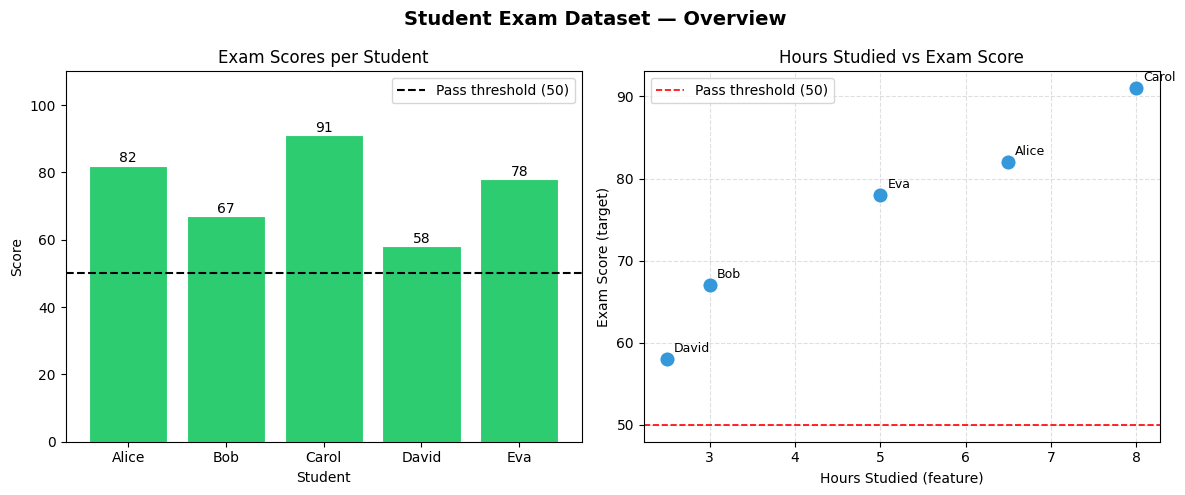


📊 Reading the charts:
  Left  — Bars above the dashed line are passing students (green);
           bars below are failing (red).
  Right — Each dot is one student. A positive trend (dots rising
           left-to-right) would suggest more study time → higher scores.
           We can already see Carol (most hours) has the highest score
           and David (fewest hours) scored the lowest.



In [19]:
import matplotlib.pyplot as plt   # industry-standard plotting library

# ── Figure setup: create a canvas with 2 side-by-side subplots ───────────────
fig, (ax1, ax2) = plt.subplots(
    nrows=1, ncols=2,              # 1 row, 2 columns
    figsize=(12, 5)                # width=12 inches, height=5 inches
)
fig.suptitle("Student Exam Dataset — Overview", fontsize=14, fontweight="bold")

# ════════════ Plot 1: Bar Chart — Exam Scores ════════════

# Colour each bar: green if passing, red if failing
bar_colors = ["#2ecc71" if s >= passing_threshold else "#e74c3c"
              for s in all_scores]  # list comprehension builds colour list

ax1.bar(
    student_names,      # x-axis: student names (labels)
    all_scores,         # y-axis: their scores (bar heights)
    color=bar_colors,   # colour list we just built
    edgecolor="white",  # white border between bars
    linewidth=0.8
)

# Dashed horizontal line at the pass threshold
ax1.axhline(
    y=passing_threshold,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Pass threshold ({int(passing_threshold)})"
)

# Annotate each bar with its score value
for idx, score in enumerate(all_scores):
    ax1.text(
        idx,             # x-position (matches bar index)
        score + 1,       # y-position: just above the bar top
        str(score),      # the text to display
        ha="center",     # horizontal alignment
        fontsize=10
    )

ax1.set_title("Exam Scores per Student")
ax1.set_xlabel("Student")
ax1.set_ylabel("Score")
ax1.set_ylim(0, 110)     # y-axis from 0 to 110 for annotation headroom
ax1.legend()

# ════════════ Plot 2: Scatter — Hours Studied vs Score ════════════

ax2.scatter(
    all_hours,          # x-axis: hours studied (feature / predictor)
    all_scores,         # y-axis: exam score    (target / label)
    color="#3498db",    # blue dots
    s=120,              # dot size in points²
    edgecolors="white", # white ring around each dot
    linewidth=0.8,
    zorder=3            # draw dots on top of grid lines
)

# Label each point with the student's name
for name, h, s in zip(student_names, all_hours, all_scores):
    ax2.annotate(
        name,
        xy=(h, s),              # the point to annotate
        xytext=(5, 5),          # offset in points (right and up)
        textcoords="offset points",
        fontsize=9
    )

# Dashed pass threshold line — same as the bar chart for consistency
ax2.axhline(y=passing_threshold, color="red", linestyle="--",
            linewidth=1.2, label=f"Pass threshold ({int(passing_threshold)})")

ax2.set_title("Hours Studied vs Exam Score")
ax2.set_xlabel("Hours Studied (feature)")
ax2.set_ylabel("Exam Score (target)")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.4)  # subtle grid lines

plt.tight_layout()   # automatically adjust spacing between subplots
plt.show()

print("""
📊 Reading the charts:
  Left  — Bars above the dashed line are passing students (green);
           bars below are failing (red).
  Right — Each dot is one student. A positive trend (dots rising
           left-to-right) would suggest more study time → higher scores.
           We can already see Carol (most hours) has the highest score
           and David (fewest hours) scored the lowest.
""")

---
## ✅ Notebook Summary & Key Takeaways

| Concept | What you learned | ML relevance |
|---------|-----------------|-------------|
| **Variables & Types** | `int`, `float`, `str`, `bool` + type casting | Every hyperparameter and metric is one of these |
| **Lists** | Indexing, slicing, `append`, `remove`, comprehensions | Feature arrays, label vectors, epoch-loss history |
| **Dictionaries** | Key-value lookup, `.items()`, nested structures | Config objects, metric containers, label maps |
| **For loops** | `enumerate`, `zip`, `range`, `break`, `continue` | Iterating over batches, epochs, feature columns |
| **While loops** | Condition-based repetition, safety caps | Early stopping, iterative solvers |
| **Functions** | `def`, parameters, defaults, `return`, docstrings | Reusable preprocessing and evaluation helpers |
| **Mini pipeline** | Chaining all of the above end-to-end | The skeleton of every ML script you'll ever write |

---
